In [1]:
from dataclasses import asdict
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

import scarf

scarf.configure_output(level="WARNING", progress=False)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    "tenx_5K_pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
ds = scarf.DataStore(f"{dataset}/data.zarr", nthreads=4)
clustering_run = ds.pipeline.open(label="docs_default")
graph = clustering_run["connectivity_map"]
umap = clustering_run["umap"]
umap_values = np.asarray(ds.load_artifact(umap)["values"][:])

In [2]:
leiden_refs = {
    0.3: ds.run_leiden_clustering(graph, resolution=0.3),
    0.5: clustering_run["leiden_0.5"],
    0.8: ds.run_leiden_clustering(graph, resolution=0.8),
}
leiden_values = {
    resolution: np.asarray(ds.load_artifact(ref)["values"][:])
    for resolution, ref in leiden_refs.items()
}

pd.DataFrame(
    {
        resolution: pd.Series(values).value_counts()
        for resolution, values in leiden_values.items()
    }
).fillna(0).astype(int)

,0.3,0.5,0.8
1,716,716,336
2,239,25,377
3,1310,239,28
4,927,1241,239
5,318,434,560
6,142,319,707
7,256,552,289
8,25,151,29
9,15,256,236
10,0,15,309


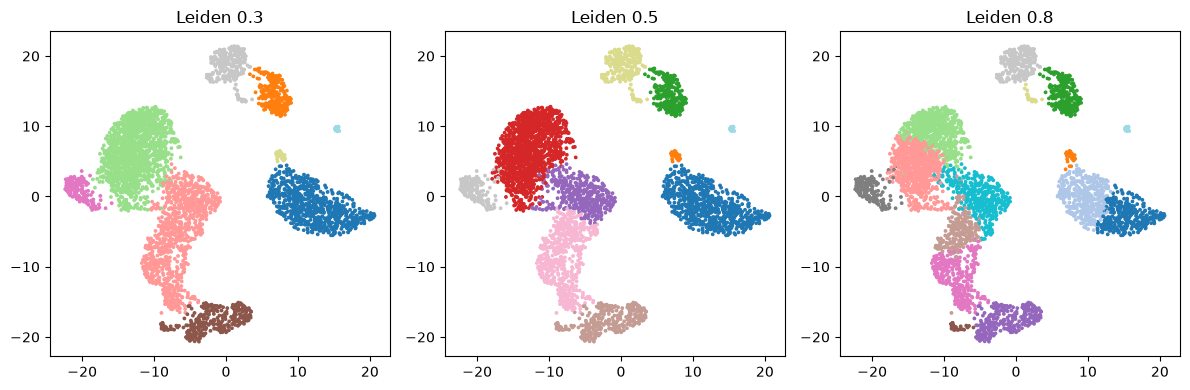

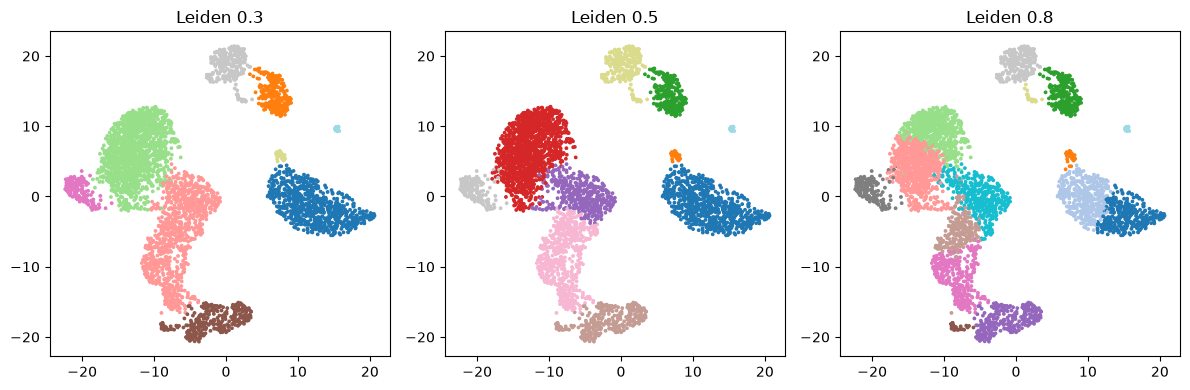

In [3]:
figure, axes = plt.subplots(1, 3, figsize=(12, 4))
for axis, resolution in zip(axes, leiden_values, strict=True):
    axis.scatter(
        umap_values[:, 0],
        umap_values[:, 1],
        c=leiden_values[resolution],
        s=3,
        cmap="tab20",
    )
    axis.set_title(f"Leiden {resolution}")
figure.tight_layout()
figure

In [4]:
agreement = []
for first, second in combinations(leiden_values, 2):
    agreement.append(
        {
            "comparison": f"{first} vs {second}",
            "ARI": adjusted_rand_score(
                leiden_values[first],
                leiden_values[second],
            ),
            "NMI": normalized_mutual_info_score(
                leiden_values[first],
                leiden_values[second],
            ),
        }
    )
pd.DataFrame(agreement)

,comparison,ARI,NMI
0,0.3 vs 0.5,0.870890,0.919991
1,0.3 vs 0.8,0.569073,0.807202
2,0.5 vs 0.8,0.652480,0.848899


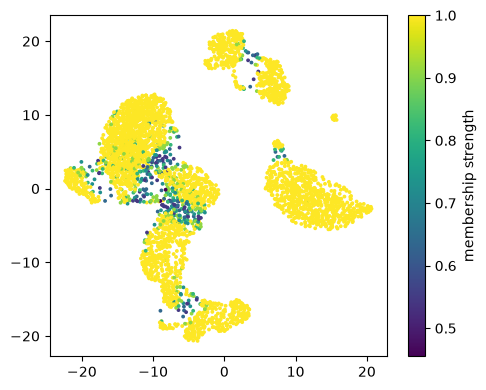

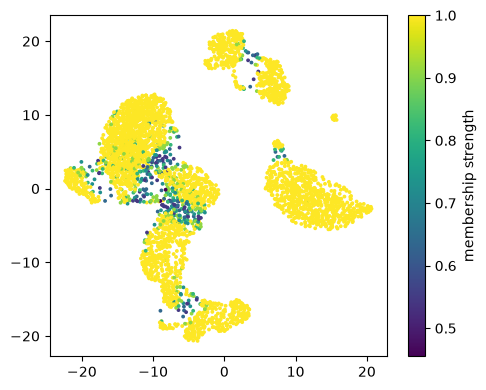

In [5]:
chosen = leiden_refs[0.5]
chosen_values = leiden_values[0.5]
membership = ds.calc_membership_strength(chosen, graph)
membership_values = np.asarray(ds.load_artifact(membership)["values"][:])

figure, axis = plt.subplots(figsize=(5, 4))
points = axis.scatter(
    umap_values[:, 0],
    umap_values[:, 1],
    c=membership_values,
    s=3,
)
figure.colorbar(points, ax=axis, label="membership strength")
figure.tight_layout()
figure

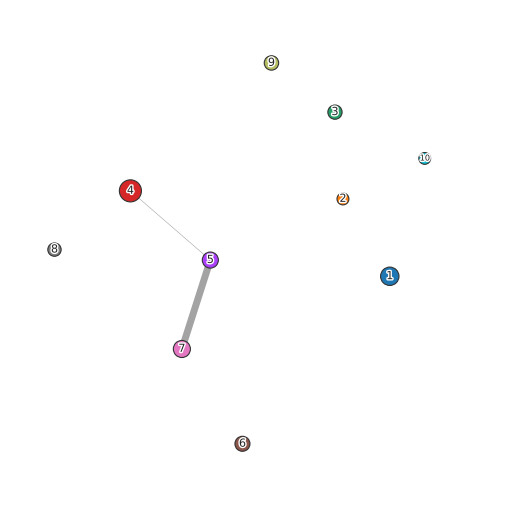

In [6]:
ds.plots.cluster_connectivity(
    graph=graph,
    groups=chosen,
    layout=umap,
)

In [7]:
paris_auto = ds.run_paris_clustering(graph)
paris_result = ds.load_paris_clustering(paris_auto)
pd.DataFrame([asdict(item) for item in paris_result.diagnostics])[
    ["label", "size", "persistence", "decision_margin", "forced"]
]

,label,size,persistence,decision_margin,forced
0,1,381,87.005282,0.106567,False
1,2,332,75.167770,0.066890,False
2,3,228,144.527046,0.560474,False
3,4,1339,430.260234,0.165564,False
4,5,284,62.717847,NaN,False
5,6,332,114.578882,0.171068,False
6,7,143,105.512744,0.649577,False
7,8,267,53.963308,NaN,False
8,9,570,109.741983,NaN,False
9,10,28,21.267540,NaN,False


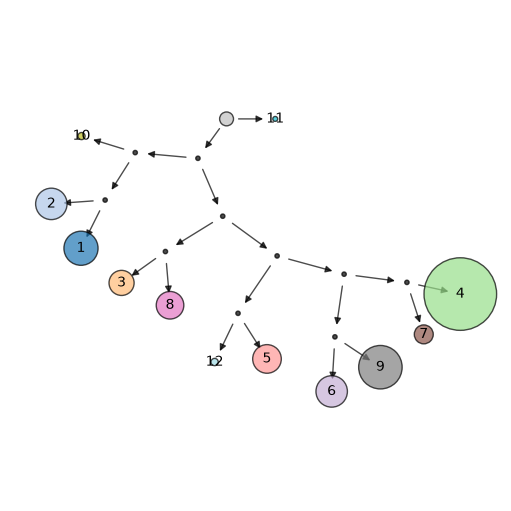

In [8]:
ds.plots.cluster_tree(graph=graph, clusters=paris_auto)

In [9]:
paris_fixed = ds.run_paris_clustering(
    graph,
    n_clusters=paris_result.n_clusters,
)
paris_auto_values = np.asarray(ds.load_artifact(paris_auto)["labels"][:])
paris_fixed_values = np.asarray(ds.load_artifact(paris_fixed)["labels"][:])
pd.Series(
    {
        "auto vs fixed ARI": adjusted_rand_score(
            paris_auto_values,
            paris_fixed_values,
        ),
        "Leiden vs Paris ARI": adjusted_rand_score(
            chosen_values,
            paris_auto_values,
        ),
    }
)

auto vs fixed ARI      0.943232
Leiden vs Paris ARI    0.791518
dtype: float64

In [10]:
markers = ds.run_marker_search(
    chosen,
    features=clustering_run["feature_universe"],
)
sizes = pd.Series(chosen_values).value_counts()
largest = sizes.index[0]
smallest = sizes.index[-1]

largest_markers = ds.get_markers(marker=markers, group_id=largest)
smallest_markers = ds.get_markers(marker=markers, group_id=smallest)

In [11]:
largest_markers[
    ["feature_name", "score", "auc", "p_value", "p_value_adjusted"]
].head(10)

,feature_name,score,auc,p_value,p_value_adjusted
0,ADTRP,0.61890,0.60920,3.580369e-108,6.286828e-106
1,FHIT,0.51857,0.77473,3.305650e-282,3.695496e-279
2,TSHZ2,0.48540,0.63679,6.612532e-118,1.327971e-115
3,TCEA3,0.48253,0.59006,2.671241e-75,2.509470e-73
4,CHRM3-AS2,0.46413,0.66321,7.806746e-146,2.218836e-143
5,CMTM8,0.43859,0.61914,1.037609e-85,1.298483e-83
6,EPHX2,0.43070,0.66277,6.659238e-138,1.731299e-135
7,MAN1C1,0.42497,0.62275,2.670897e-85,3.293256e-83
8,NOG,0.42190,0.61849,1.471531e-118,2.973024e-116
9,LRRN3,0.39995,0.73614,9.865691e-246,7.519899e-243


In [12]:
smallest_markers[
    ["feature_name", "score", "auc", "p_value", "p_value_adjusted"]
].head(10)

,feature_name,score,auc,p_value,p_value_adjusted
0,TPM2,0.83726,0.96477,7.923809e-68,2.438062e-65
1,SERPINF1,0.82985,0.99685,1.200639e-123,6.711172e-121
2,MAP1A,0.81256,0.96035,2.330331e-109,1.070611e-106
3,LILRA4,0.81141,0.99976,2.403755e-215,2.303346e-212
4,IL3RA,0.80536,1.00000,9.536887e-170,7.269275e-167
5,SMPD3,0.79616,0.99775,2.867716e-210,2.671596e-207
6,DNASE1L3,0.79286,0.99868,6.656585e-193,5.874962e-190
7,GAS6,0.78312,0.99888,3.028428e-271,5.078371e-268
8,DERL3,0.77951,0.96440,1.351287e-130,8.092761e-128
9,FCER1A,0.76586,0.82674,6.683680e-63,1.949194e-60
